##### Transfer Learning with Inceptionv3 on CIFAR-10 in Keras

In [1]:
from tensorflow.keras.applications.inception_v3 import InceptionV3,preprocess_input
import tensorflow as tf
from tensorflow.keras import optimizers,models
import tensorflow.keras as keras
from tensorflow.keras.utils import to_categorical
from keras.models import load_model
from keras.preprocessing import image
from keras.datasets import cifar10
import numpy as np
from matplotlib import pyplot as plt
import cv2 as cv
from keras.models import Model
from keras.layers import UpSampling2D,Flatten

###### Pretrained Model Loading

In [2]:
conv_base = InceptionV3(weights='imagenet',include_top=False,input_shape=(224,224,3))

In [3]:
conv_base.input

<KerasTensor shape=(None, 224, 224, 3), dtype=float32, sparse=False, ragged=False, name=keras_tensor>

In [4]:
for layer in conv_base.layers:
    print(layer)

<InputLayer name=input_layer, built=True>
<Conv2D name=conv2d, built=True>
<BatchNormalization name=batch_normalization, built=True>
<Activation name=activation, built=True>
<Conv2D name=conv2d_1, built=True>
<BatchNormalization name=batch_normalization_1, built=True>
<Activation name=activation_1, built=True>
<Conv2D name=conv2d_2, built=True>
<BatchNormalization name=batch_normalization_2, built=True>
<Activation name=activation_2, built=True>
<MaxPooling2D name=max_pooling2d, built=True>
<Conv2D name=conv2d_3, built=True>
<BatchNormalization name=batch_normalization_3, built=True>
<Activation name=activation_3, built=True>
<Conv2D name=conv2d_4, built=True>
<BatchNormalization name=batch_normalization_4, built=True>
<Activation name=activation_4, built=True>
<MaxPooling2D name=max_pooling2d_1, built=True>
<Conv2D name=conv2d_8, built=True>
<BatchNormalization name=batch_normalization_8, built=True>
<Activation name=activation_8, built=True>
<Conv2D name=conv2d_6, built=True>
<Conv2D

###### Freezing Layers

In [5]:
for layer in conv_base.layers:
    layer.trainable = False

In [6]:
for layer in conv_base.layers:
    print(layer.name,layer.trainable)

input_layer False
conv2d False
batch_normalization False
activation False
conv2d_1 False
batch_normalization_1 False
activation_1 False
conv2d_2 False
batch_normalization_2 False
activation_2 False
max_pooling2d False
conv2d_3 False
batch_normalization_3 False
activation_3 False
conv2d_4 False
batch_normalization_4 False
activation_4 False
max_pooling2d_1 False
conv2d_8 False
batch_normalization_8 False
activation_8 False
conv2d_6 False
conv2d_9 False
batch_normalization_6 False
batch_normalization_9 False
activation_6 False
activation_9 False
average_pooling2d False
conv2d_5 False
conv2d_7 False
conv2d_10 False
conv2d_11 False
batch_normalization_5 False
batch_normalization_7 False
batch_normalization_10 False
batch_normalization_11 False
activation_5 False
activation_7 False
activation_10 False
activation_11 False
mixed0 False
conv2d_15 False
batch_normalization_15 False
activation_15 False
conv2d_13 False
conv2d_16 False
batch_normalization_13 False
batch_normalization_16 False
acti

###### Model Summary

In [7]:
conv_base.summary()

Model: "inception_v3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 111, 111,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 111, 111,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 111, 111,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 109, 109,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 109, 109,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 54, 54,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 54, 54,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 54, 54,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 54, 54,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 52, 52,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 52, 52,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 52, 52,    │          0 │ batch_normalizat

 Total params: 21,802,784 (83.17 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 21,802,784 (83.17 MB)

###### Loading the CIFAR-10 Dataset

In [8]:
(x_train,y_train),(x_test,y_test) = cifar10.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

y_train = to_categorical(y_train,10)
y_test = to_categorical(y_test,10)

print(x_train.shape)
print(x_test.shape)

(50000, 32, 32, 3)
(10000, 32, 32, 3)


###### Model Architecture

In [9]:
from tensorflow.keras.layers import Resizing
from tensorflow.keras import layers

model = models.Sequential()

model.add(layers.UpSampling2D((2,2)))
model.add(layers.UpSampling2D((2,2)))
model.add(layers.UpSampling2D((2,2)))

model.add(Resizing(224,224,interpolation='bilinear'))
model.add(conv_base)

model.add(layers.Flatten())
model.add(layers.Dense(128,activation='relu'))
model.add(layers.Dropout(0.2))
model.add(layers.Dense(10,activation='softmax'))

###### Model Compilation & Training

In [10]:
from tensorflow.keras.optimizers import RMSprop
model.compile(optimizer=RMSprop(learning_rate=0.0001),loss='categorical_crossentropy',metrics=['acc'])

In [11]:
history = model.fit(x_train,y_train,steps_per_epoch=10,epochs=10,batch_size=32,validation_data=(x_test,y_test))

Epoch 1/10


2025-08-28 11:30:15.852651: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 614400000 exceeds 10% of free system memory.


10/10 ━━━━━━━━━━━━━━━━━━━━ 414s 45s/step - acc: 0.1937 - loss: 4.1636 - val_acc: 0.4514 - val_loss: 1.6176
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 399s 44s/step - acc: 0.4750 - loss: 1.6604 - val_acc: 0.5913 - val_loss: 1.2644
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 401s 44s/step - acc: 0.5688 - loss: 1.3172 - val_acc: 0.6086 - val_loss: 1.1533
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 403s 45s/step - acc: 0.6594 - loss: 1.0216 - val_acc: 0.6728 - val_loss: 1.0168
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 419s 46s/step - acc: 0.6562 - loss: 0.9722 - val_acc: 0.6730 - val_loss: 0.9892
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 422s 47s/step - acc: 0.6469 - loss: 1.0632 - val_acc: 0.7316 - val_loss: 0.8005
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 428s 47s/step - acc: 0.7125 - loss: 0.8605 - val_acc: 0.7239 - val_loss: 0.8611
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 408s 45s/step - acc: 0.7406 - loss: 0.8277 - val_acc: 0.7584 - val_loss: 0.7576
Epoch 9/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 401s 44s/step - acc: 0.7437 -

###### Model save

In [13]:
model.save("cifar_model.h5")

In [14]:
model = tf.keras.models.load_model('cifar_model.h5')

Input Dimensions - Image: (500, 500, 3)


(np.float64(-0.5), np.float64(499.5), np.float64(499.5), np.float64(-0.5))

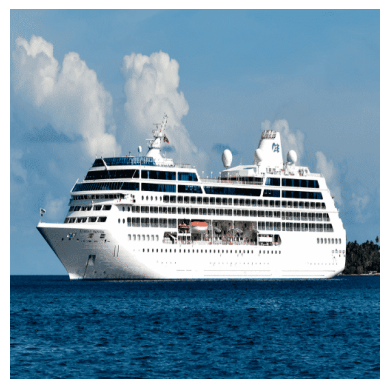

In [27]:
import cv2 as cv
from skimage import io

input_img = 'https://www.marineinsight.com/wp-content/uploads/2019/08/Cruise-ships-1.png'
input_img = io.imread(input_img)
input_img = cv.resize(input_img,dsize=(500,500),interpolation=cv.INTER_CUBIC)
print('Input Dimensions - Image:',input_img.shape)
plt.imshow(input_img)
plt.axis('off')


In [24]:
import keras.utils as img

input_image = cv.resize(input_img,dsize=(224,224),interpolation=cv.INTER_CUBIC)
x = image.img_to_array(input_image)
x = np.expand_dims(x,axis=0)
x = preprocess_input(x)
preds = model.predict(x)
class_idx = np.argmax(preds[0])

preds[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


array([0.00773555, 0.00492378, 0.03249367, 0.00223896, 0.03520431,
       0.00435816, 0.0296397 , 0.0061045 , 0.8759542 , 0.00134719],
      dtype=float32)

In [25]:
class_idx

np.int64(8)

In [15]:
# 0: airplane,1:automobile,2:bird,3:cat,4:deer,5:dog,6:frog,7:horse,8:ship,9:truck